In [27]:
##Importing packages
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st
from numpy.polynomial.legendre import legvander
import yaml
print("All packages imported.")


##Importing temperature fit posteriors
with open('temperature_posterior_params.yaml', 'r') as f:
    data = yaml.unsafe_load(f)

print(data['ref_temps'].keys())

All packages imported.
dict_keys(['0', '1', '2', '3', '4'])


(50,)


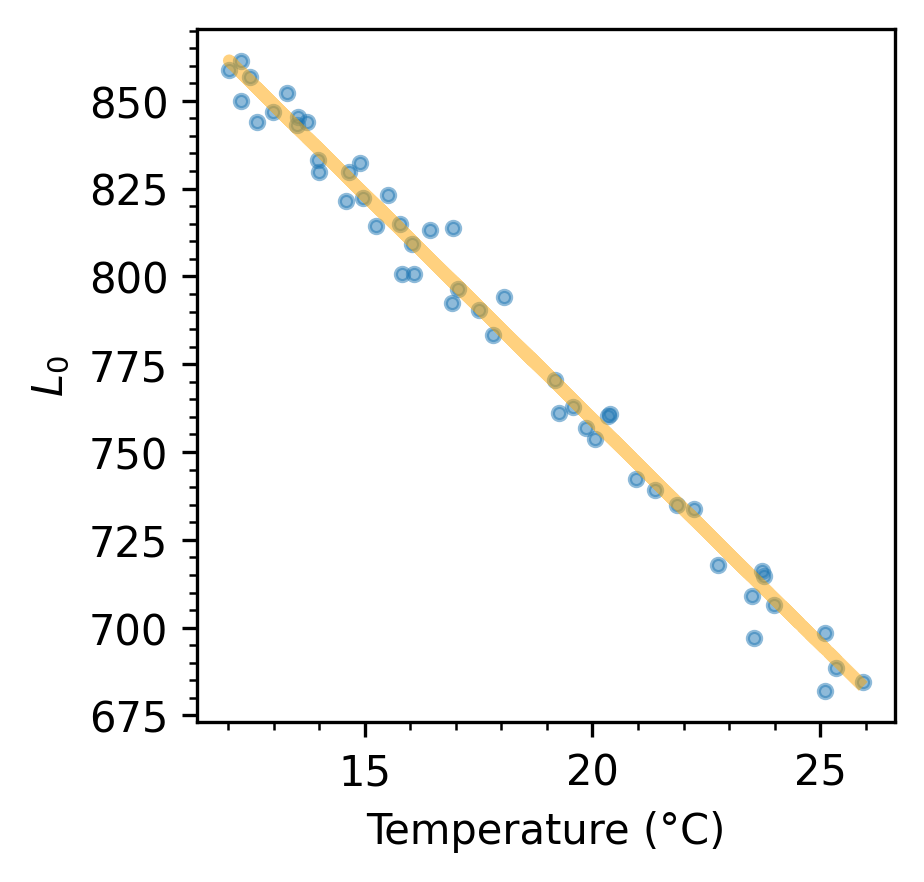

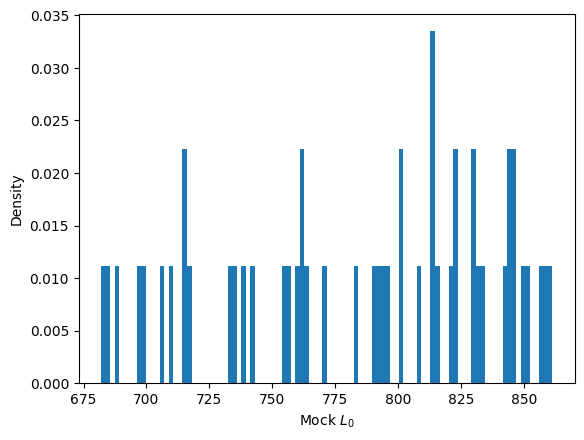

In [28]:
##Generating the constant offset

#Importing temperature posteriors (calculated courtesy of Mike) (selecting POINTING 0)
#Order is 3,1,0,2,4
slope = np.array([-12.793660163879395, -12.989282608032227, -12.83067512512207, -13.617277145385742, -12.889981269836426])
beta = np.array([1.5593849420547485, 1.4276649951934814, 1.6162447929382324, 1.5924253463745117, 1.6654024124145508])    #Shape
alpha = np.array([8.69485092163086, 19.629505157470703, 22.034549713134766, 23.452856063842773, 24.416927337646484])   #Scale
y_int = np.array([767.27099609375, 773.8646240234375, 756.2579956054688, 807.997314453125, 781.35986328125])
T_0 = np.array([19.382335662841797, 19.38233566284179, 20.202392578125, 20.401718139648438, 19.520580291748047]) #Temperature centre offset
dots = 50 #How many points to generate
temps = np.random.uniform(12, 26, size=(dots,)) #Randomly generating temperatures
amps = np.empty(shape=(dots, ))#slope.shape[0]))
print(amps.shape)

plt.figure(figsize=(3, 3), dpi=300)
j = 0 #Pointing 0
amps = slope[j] * (temps - T_0[j]) + y_int[j] + st.gennorm.rvs(beta[j], 0, alpha[j], size=(dots,))
plt.scatter(temps, amps, s=10, label=j, alpha=0.5)
T = np.linspace(temps.min(), temps.max(), 10000)
plt.plot(temps, slope[j]*(temps-T_0[j]) + y_int[j], color='orange', alpha=0.5, linestyle='--', linewidth=3)
#plt.legend(title="Pointing")
plt.xlabel("Temperature (°C)")
plt.ylabel(r"$L_0$")
plt.minorticks_on()
plt.show()

plt.hist(np.ndarray.flatten(amps), bins=100, density=True)
plt.xlabel(r'Mock $L_0$')
plt.ylabel("Density")
plt.show()

/var/folders/m_/qdkhzz6n1j3_fjt6_pj6ycv40000gn/T/ipykernel_23168/3108738732.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  fire[i] = st.gennorm.rvs(*fits[i, :], size=(1,))


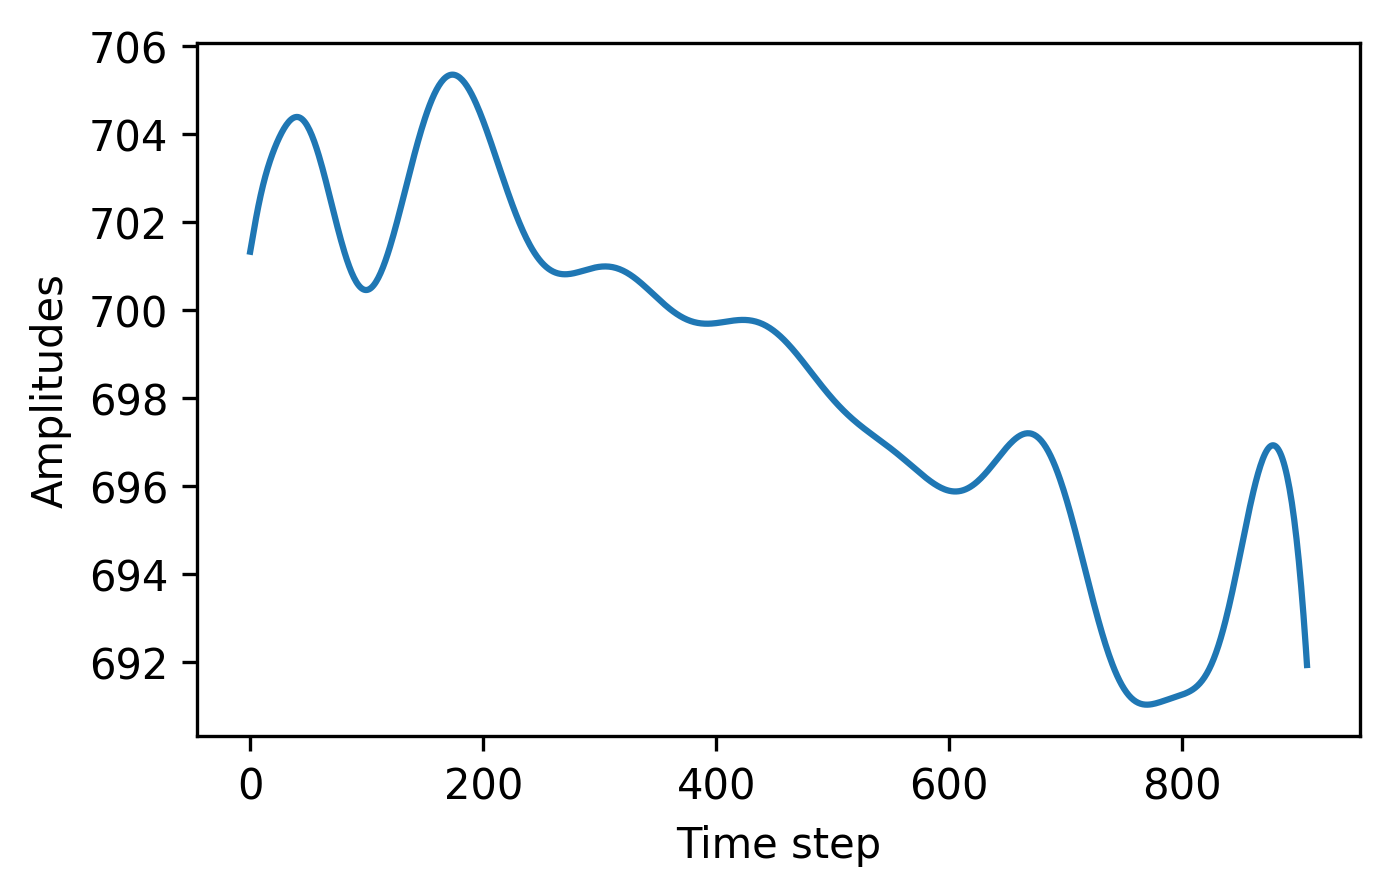

(908,)


In [29]:
##Generating smooth background

#Summoning the L-coefficient parameters file
fits = np.load('coeff_params_gnorm.npy')[:, :]
fire = np.empty_like(fits[:, 0])

for i in range(fire.shape[0]):
    fire[i] = st.gennorm.rvs(*fits[i, :], size=(1,))
fire = np.array(fire)

rand_amp = np.random.choice(np.ndarray.flatten(amps))
fire[0] = rand_amp
temp_drawn = temps[amps == rand_amp]

cut = 20

mask = np.load('mask_example.npy').astype(bool)
scale = mask.shape[0] + 2 * cut

lims = 907

x = np.linspace(-1, 1, scale)
X = legvander(x, fits.shape[0]-1)

background = (X @ fire)[cut:-cut]

plt.figure(dpi=300, figsize=(5,3))
plt.plot(background)
#plt.xlim(scale-lims, 2*lims-scale)
plt.xlabel("Time step")
plt.ylabel("Amplitudes")
plt.show()
print(background.shape)

(908,)


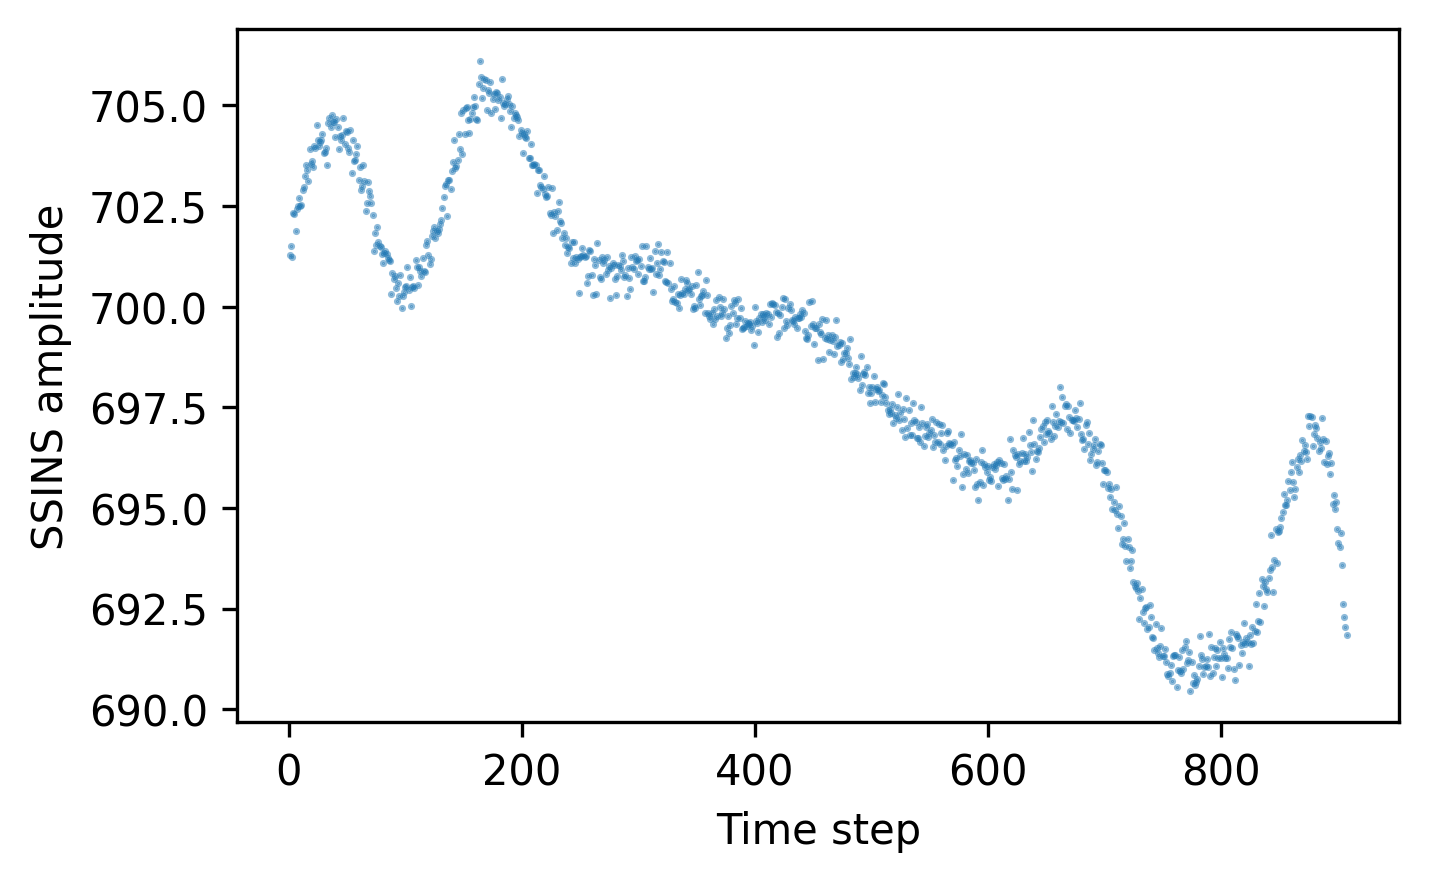

In [30]:
##Generating noise

N_bl = 8000
N_freq = 175

prefac = (4/np.pi-1)/(N_bl*N_freq)
for i in range(background.shape[0]):
    sigma = np.sqrt(prefac)*background[i]
    noise = st.norm.rvs(loc=0, scale=sigma)
    background[i] += noise
print(background.shape)

plt.figure(dpi=300, figsize=(5,3))
plt.scatter(np.arange(1, scale - 2 * cut +1, 1), background, alpha=0.5, s=0.5)
#plt.xlim(scale-lims, 2*lims-scale)

plt.xlabel("Time step")
plt.ylabel("SSINS amplitude")
plt.show()

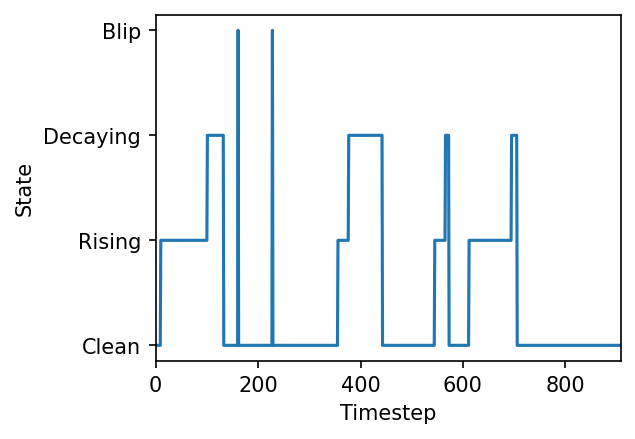

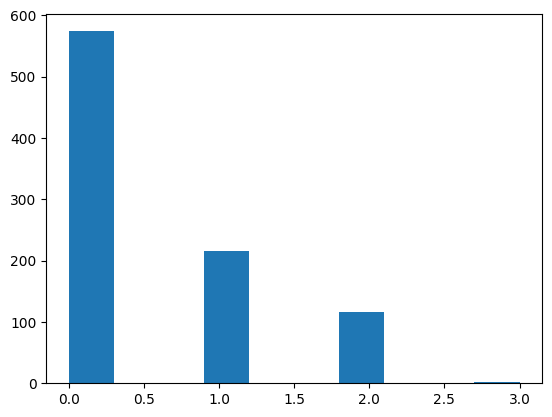

In [31]:
##Generating random sequence


#Transition matrix
""" next_matrix = np.array([[0.99, 0.005, 0, 0.005],
                        [0, 0.97, 0.03, 0.00], 
                        [0.01, 0, 0.99, 0.00],
                        [1, 0.00, 0.00, 0]])
 """

next_matrix = np.array([[0.99, 0.005, 0, 0.005],
                        [0, 0.97, 0.03, 0.00], 
                        [0.03, 0, 0.97, 0.00],
                        [1, 0.00, 0.00, 0]])

#Initializing chains
initial_cond = 0
chain = np.zeros(shape=(scale - 2 * cut, ))
chain[0] = initial_cond
for i in range(scale - 2 * cut - 1):
    chain[i + 1] = np.random.choice(a=[0, 1, 2, 3], p=next_matrix[int(chain[i]), :])

plt.figure(figsize=(4, 3), dpi=150)
plt.plot(chain)
plt.xlabel("Timestep")
plt.ylabel("State")
plt.yticks([0,1,2,3], ['Clean', 'Rising', 'Decaying', 'Blip'])
plt.xlim(0, 908)
plt.show()
plt.hist(chain)
plt.show()

#Defining some fiducial parameters
l_rise = 1.05
l_decay = 1/l_rise
mu_blip = 0
s_blip = 10

#Throwing in some random noise to seed the emissions
seed_gen = np.random.exponential(scale=0.3, size=(scale - 2 * cut, ))
rfi_inject = np.copy(seed_gen)

for i in range(chain.shape[0]):

    delta_amp = np.random.uniform(0.7, 3.5)
    if chain[i] == 1:
        rfi_inject[i] = l_rise * rfi_inject[i-1]
    if chain[i] == 2:
        rfi_inject[i] = l_decay * rfi_inject[i-1]
    if chain[i] == 3:
        rfi_inject[i] += st.t.rvs(df=3, loc=3, scale=1) #previously set to loc=1, scale=1

rfi_inject[rfi_inject == seed_gen] = 0


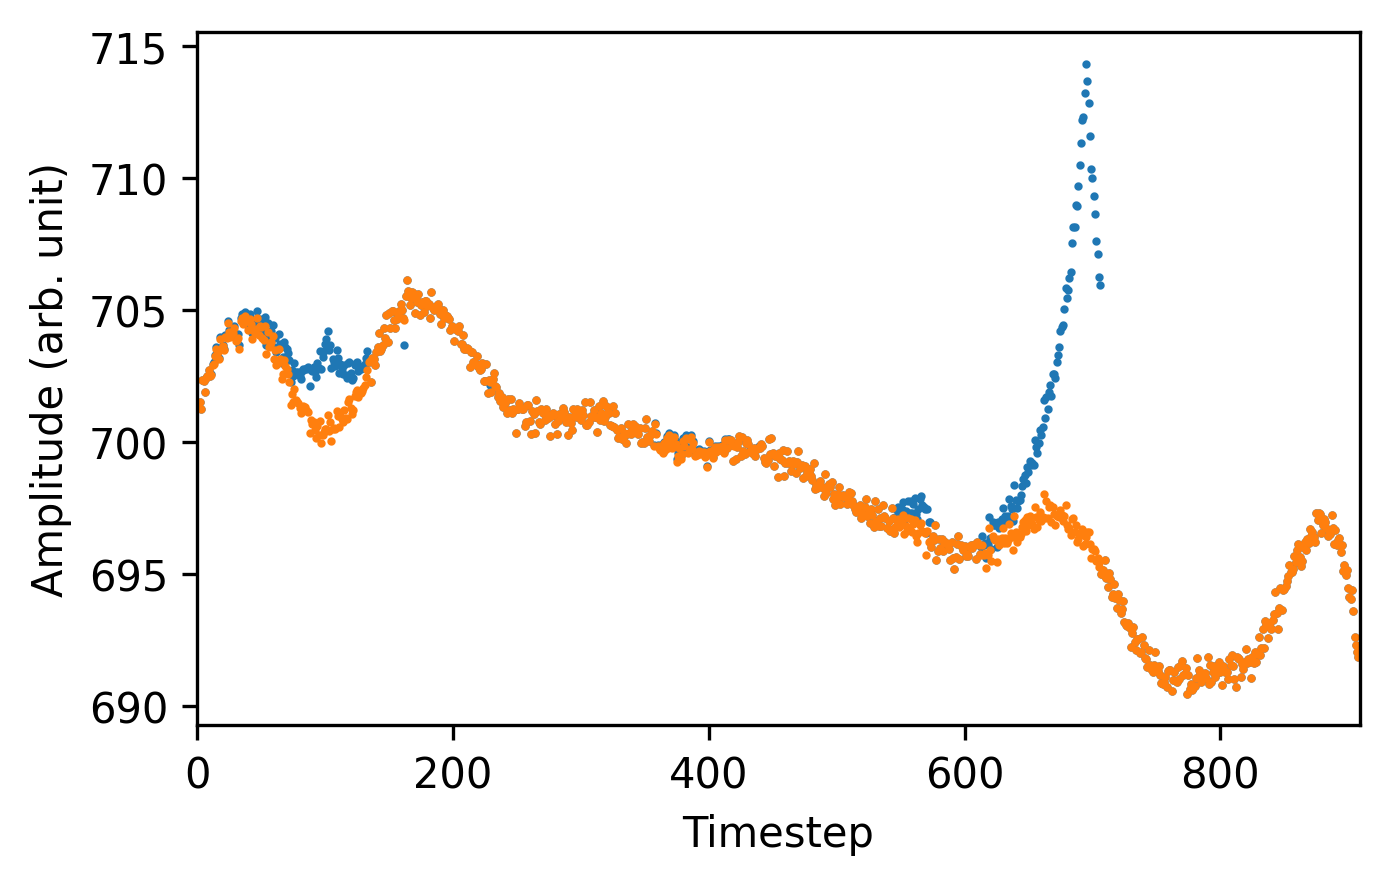

In [32]:
##Building up RFI + background
mock_data = background + rfi_inject
plt.figure(figsize=(5, 3), dpi=300)
plt.xlim(0, scale - 2 * cut +1)
plt.xlabel("Timestep")
plt.ylabel("Amplitude (arb. unit)")
plt.scatter(np.arange(1, scale - 2 * cut +1, 1), mock_data, s=1)
plt.scatter(np.arange(1, scale - 2 * cut +1, 1), background, s=1)
plt.show()

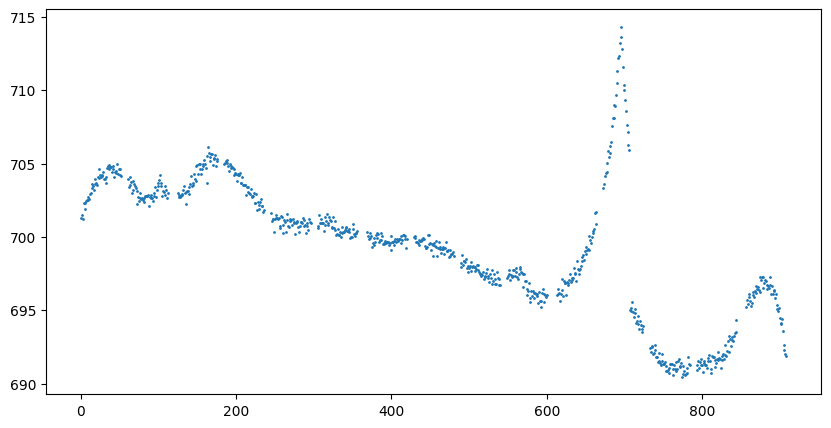

[25.11615104]


In [33]:
#Putting in gaps
gappy_mock = np.where(mask, np.nan, mock_data)
plt.figure(figsize=(10, 5))
plt.scatter(np.arange(1, scale - 2 * cut +1, 1), gappy_mock, s=1)
#plt.fill_between(np.arange(1, scale - 2 * cut +1, 1), np.mean(background) - np.sqrt(prefac)*np.mean(background), np.mean(background) + np.sqrt(prefac)*np.mean(background))
plt.show()

print(temp_drawn)
#np.save('mock_data_l5/run_40.npy', gappy_mock)

In [34]:
##Running multiple times to get some emissions and blips

runs = 4000
lim = 5
blips = np.zeros(shape=(runs, ))
emissions = np.zeros(shape=(runs, ))
bias_blips = np.zeros(shape=(runs, lim))
bias_emissions = np.zeros(shape=(runs, lim))


next_matrix = np.array([[0.99, 0.005, 0, 0.005],
                        [0, 0.97, 0.03, 0.00], 
                        [0.01, 0, 0.99, 0.00],
                        [1, 0.00, 0.00, 0]])

occupancy = np.empty(shape=(runs, 2))
emit_bright = np.array([])
blip_bright = np.array([])

for go in range(runs):

    # This is for generating random Markov chains: replace with whatever 2D array you want to call
    initial_cond = 0
    chain = np.zeros(shape=(scale - 2 * cut, ))
    chain[0] = initial_cond

    for i in range(scale - 2 * cut - 1):
        chain[i + 1] = np.random.choice(a=[0, 1, 2, 3], p=next_matrix[int(chain[i]), :])
    
    # This is actually where it counts RFI: it looks for where chain = 3 (blip)
    # and where chain goes 0 => 1 (emission), then adds it to the counts arrays
    blips[go] = np.array(np.where(chain == 3)).shape[1]
    emissions[go] = np.array(np.where((chain[:-1] == 0) & (chain[1:] == 1))).shape[1]

    #seed_gen = np.random.exponential(scale=0.3, size=(scale - 2 * cut, ))
    #rfi_inject = np.copy(seed_gen)

    #Generating RFI events based off of RFI
    for i in range(chain.shape[0]):
        if chain[i] == 1:
            rfi_inject[i] = l_rise * rfi_inject[i-1] #Rising
        if chain[i] == 2:
            rfi_inject[i] = l_decay * rfi_inject[i-1] #Falling
        if chain[i] == 3:
            rfi_inject[i] += np.abs(st.t.rvs(df=3, loc=1, scale=1)) #Blip: previously set to loc=1, scale=1
    rfi_inject[rfi_inject == seed_gen] = 0

    #Looking at occupancy
    occupancy[go, 0] = (chain[(chain == 1)].shape[0] + chain[(chain == 2)].shape[0])/chain.shape[0]
    occupancy[go, 1] = chain[chain == 3].shape[0]/chain.shape[0]

    #Looking at brightness occupancies
    emit_bright = np.append(emit_bright, rfi_inject[(chain == 1) | (chain == 2)])
    blip_bright = np.append(blip_bright, rfi_inject[chain == 3])

    #Looking at observational biases from implementing minimum cutoff for RFI amplitude
    for m in range(0, lim):
        bias_blips[go, m] = np.array(np.where((chain == 3) & (rfi_inject > 0.33*(m + 1)))).shape[1]
        bias_emissions[go, m] = np.array(np.where((chain[:-1] == 1) & (chain[1:] == 2) & (rfi_inject[1:] > 0.33*(m + 1)))).shape[1]

    print(go + 1, end='\r')

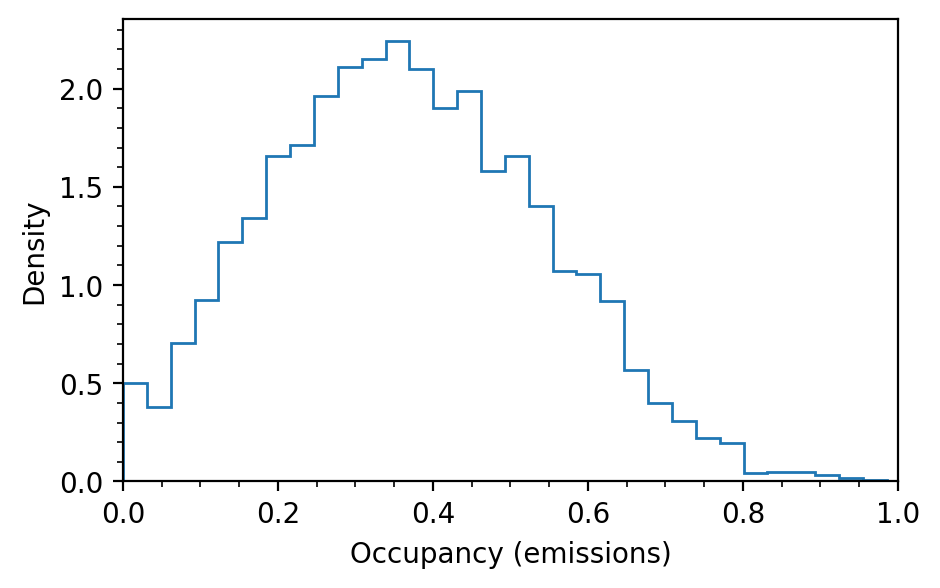

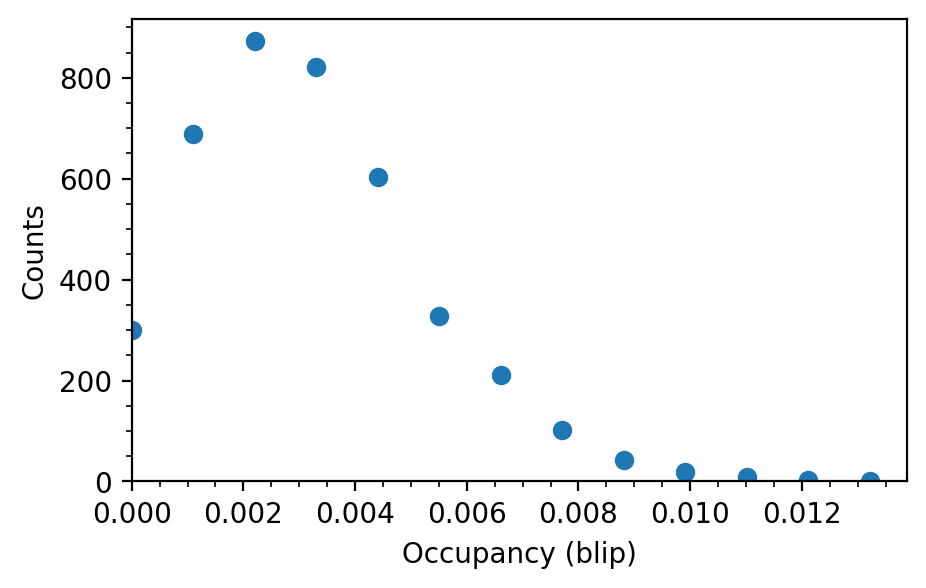

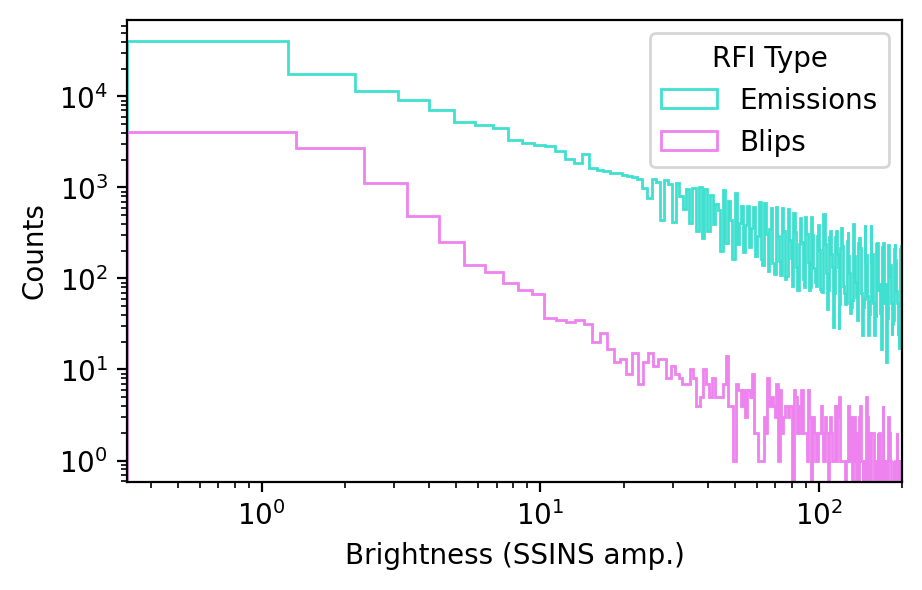

In [35]:
#Looking at occupancy and RFI brightness amplitude distributions

plt.figure(figsize=(5, 3), dpi=200)
plt.minorticks_on()
plt.hist(occupancy[:, 0], label='Emission', bins='auto', density=True, histtype='step')
plt.xlim(0, 1)
#plt.yscale('log')
plt.xlabel('Occupancy (emissions)')
plt.ylabel('Density')
plt.show()

plt.figure(figsize=(5, 3), dpi=200)
plt.minorticks_on()
plt.scatter(np.arange(0, np.bincount((occupancy[:, 1]*(scale - 2 * cut)).astype('int')).shape[0])/(scale - 2 * cut),
         np.bincount((occupancy[:, 1]*(scale - 2 * cut)).astype('int')), label='Blip')
plt.ylim(0)
plt.xlim(left=0)
plt.xlabel('Occupancy (blip)')
plt.ylabel('Counts')
plt.show()

plt.figure(figsize=(5, 3), dpi=200)
plt.minorticks_on()
plt.hist(emit_bright[(emit_bright > 0.33) & (emit_bright < 200)], bins='auto', histtype='step', label='Emissions', color='turquoise')
plt.hist(blip_bright[(blip_bright > 0.33) & (blip_bright < 200)], bins='auto', histtype='step', label='Blips', color='violet')
plt.legend(title='RFI Type')
plt.xlim(left=0.33, right=200)
plt.xlabel('Brightness (SSINS amp.)')
plt.yscale('log')
plt.xscale('log')
plt.ylabel('Counts')
plt.show()

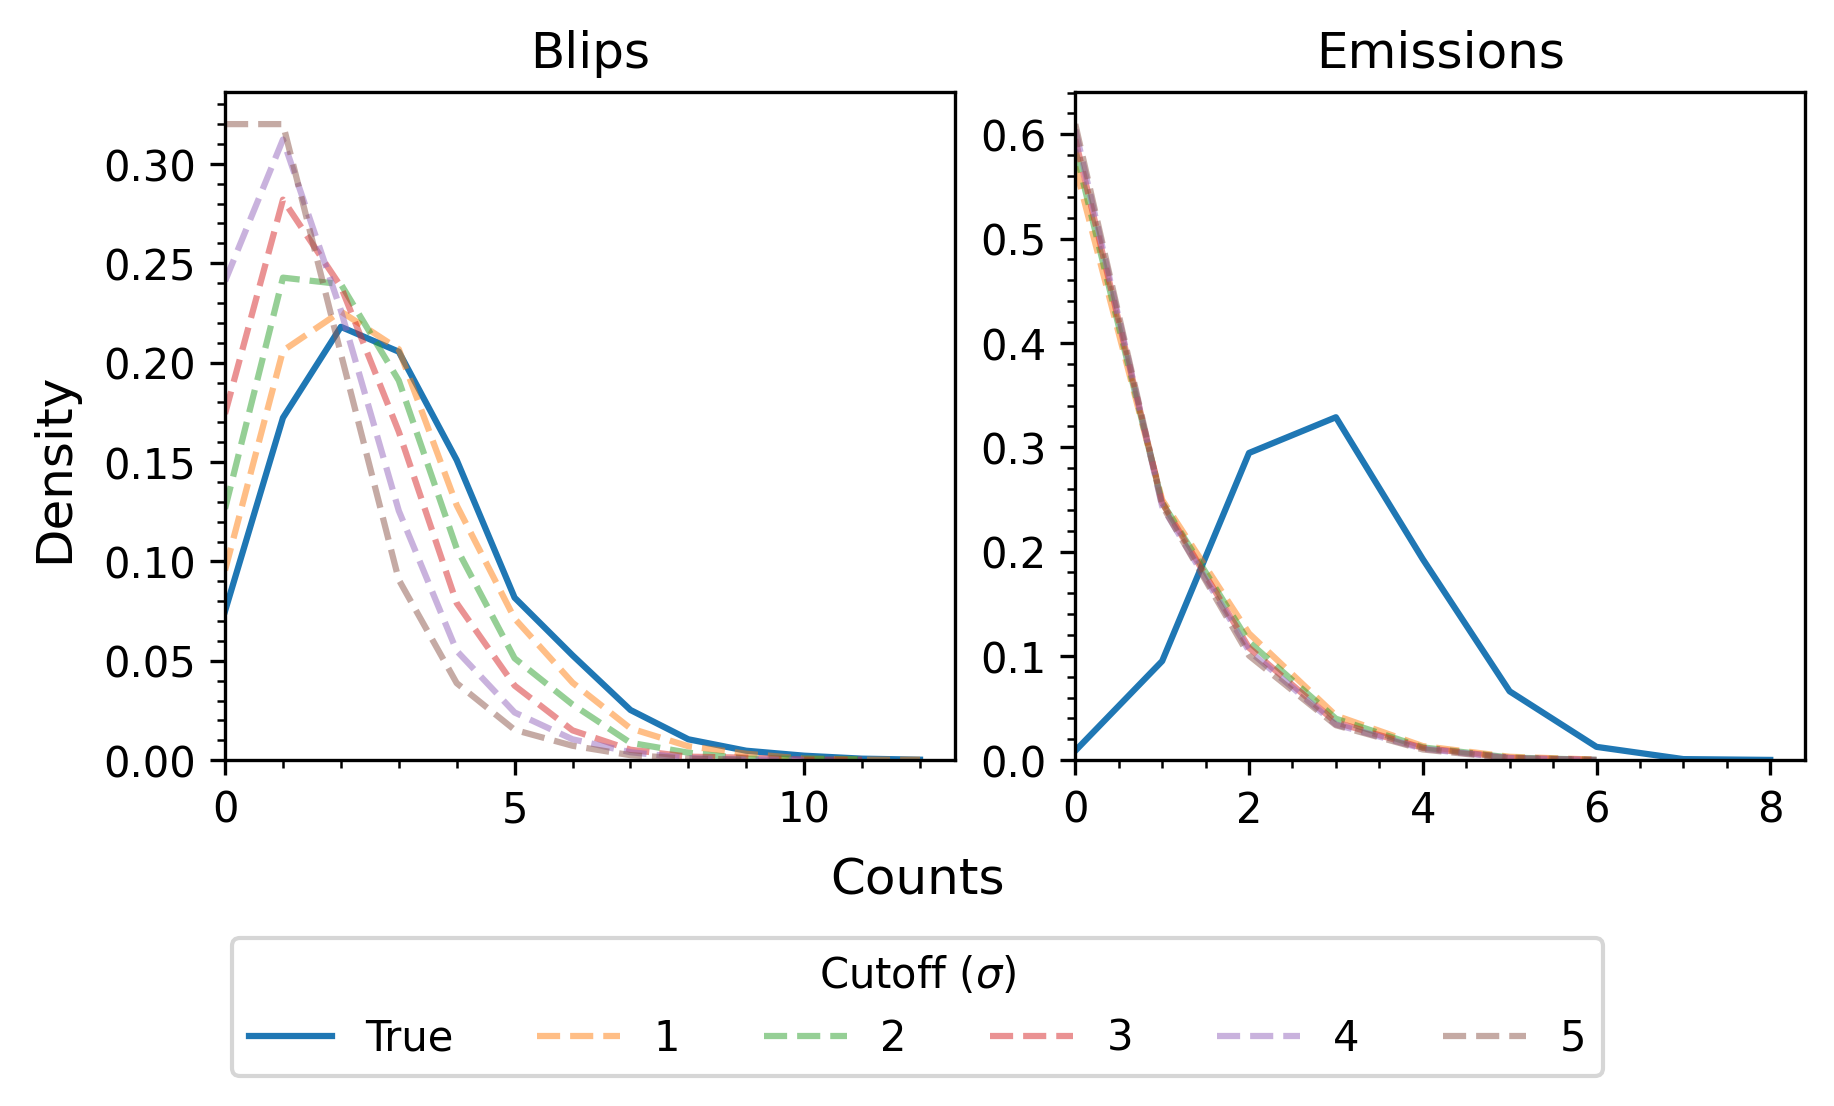

In [36]:
##Looking at the bias from significance threshold counting

fig, ax = plt.subplots(dpi=300, figsize=(6, 3), ncols=2)

ax[0].plot(np.bincount(blips.astype('int'))/np.sum(np.bincount(blips.astype('int'))), label='True')
for m in range(0, lim):
    ax[0].plot(np.bincount(bias_blips[:, m].astype('int'))/np.sum(np.bincount(bias_blips[:, m].astype('int'))), label=m + 1, alpha=0.5, linestyle='--')
ax[0].set_title("Blips")
ax[0].set_xlim(0)
ax[0].set_ylim(0)

fig.legend(title=r"Cutoff ($\sigma$)", loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=6)

ax[1].plot(np.bincount(emissions.astype('int'))/np.sum(np.bincount(emissions.astype('int'))), label='True')
for m in range(0, lim):
    ax[1].plot(np.bincount(bias_emissions[:, m].astype('int'))/np.sum(np.bincount(bias_emissions[:, m].astype('int'))), label=m+1, alpha=0.5, linestyle='--')
ax[1].set_title("Emissions")
fig.supylabel("Density")
ax[1].set_xlim(0)
ax[1].set_ylim(0)
fig.set_constrained_layout('on')
ax[0].minorticks_on()
ax[1].minorticks_on()
fig.supxlabel("Counts")
plt.show()

2.89125 1.8812026572116043
2.85675 1.1527052691386466


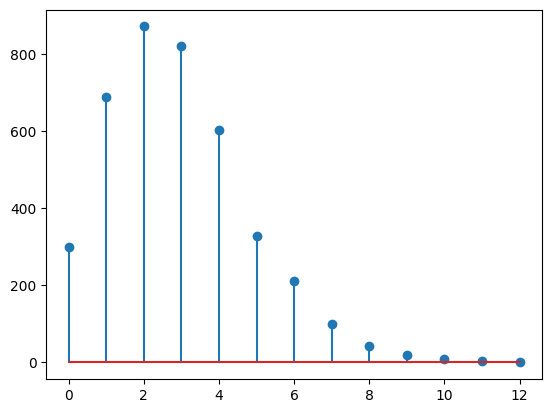

(871,)
[300 689 872 822 604 327 211 101  42  19   9   3   1]


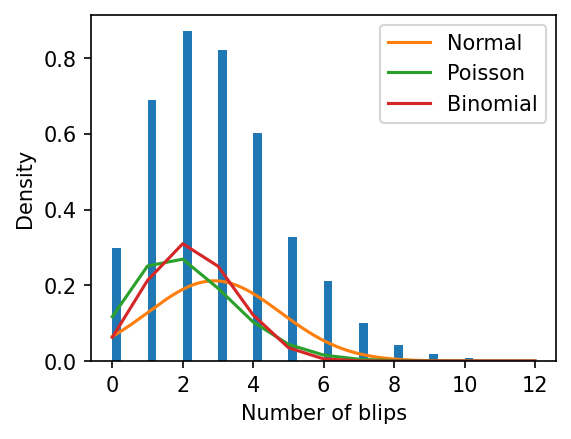

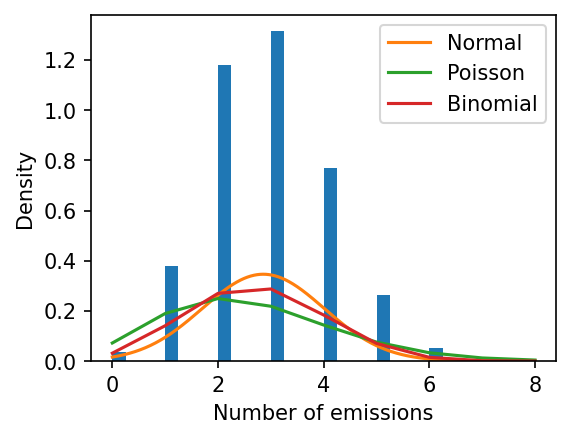

11565.0
[0.32658673] [0.38980535]


In [37]:
##Fitting some analytic PDFs to the counts distributions

from scipy.stats import norm, poisson, binom
from scipy.optimize import curve_fit

#Blip params, norm
loc_1, scale_1 = norm.fit(blips)
print(loc_1, scale_1)

#Emit params, norm
loc_2, scale_2 = norm.fit(emissions)
print(loc_2, scale_2)

def fishy(k, lamb):
    return poisson.pmf(k, lamb)

def twonom(k, p):
    return binom.pmf(k, 7, p)

plt.stem(np.bincount(blips.astype('int')))
plt.show()

##Blip parameters, Poisson
print(np.arange(np.bincount(blips.astype('int')).min(),
                              np.bincount(blips.astype('int')).max()).shape)
print(np.bincount(blips.astype('int')))
params1 = curve_fit(fishy,
                    np.arange(0, np.bincount(blips.astype('int')).shape[0]),
                    np.bincount(blips.astype('int')))[0]
b_params1 = curve_fit(twonom,
                      np.arange(0, np.bincount(blips.astype('int')).shape[0]),
                      np.bincount(blips.astype('int')), p0=0.005)[0]

##Emissions parameters, Poisson
params2 = curve_fit(fishy,
                    np.arange(0, np.bincount(emissions.astype('int')).shape[0]),
                    np.bincount(emissions.astype('int')))[0]
b_params2 = curve_fit(twonom,
                      np.arange(0, np.bincount(emissions.astype('int')).shape[0]),
                      np.bincount(emissions.astype('int')), p0=0.005)[0]

x = np.linspace(blips.min(), blips.max(), 1000)
plt.figure(figsize=(4, 3), dpi=150)
plt.hist(blips, bins='auto', density=True)
#plt.yscale('log')
plt.plot(x, norm.pdf(x, loc_1, scale_1), label='Normal')
plt.plot(np.arange(0, np.bincount(blips.astype('int')).shape[0]),
         fishy(np.arange(blips.min(), blips.max() + 1), params1[0]), label='Poisson')
plt.plot(np.arange(0, np.bincount(blips.astype('int')).shape[0]),
         twonom(np.arange(0, np.bincount(blips.astype('int')).shape[0]), *b_params1), label='Binomial')
plt.legend()
plt.xlabel('Number of blips')
plt.ylabel('Density')
plt.show()

y = np.linspace(emissions.min(), emissions.max(), 1000)
plt.figure(figsize=(4, 3), dpi=150)
plt.hist(emissions, bins='auto', density=True)
#plt.yscale('log')
plt.plot(y, norm.pdf(y, loc_2, scale_2), label='Normal')
plt.plot(np.arange(0, np.bincount(emissions.astype('int')).shape[0]),
         fishy(np.arange(0, np.bincount(emissions.astype('int')).shape[0]), params2[0]), label='Poisson')
plt.plot(np.arange(0, np.bincount(emissions.astype('int')).shape[0]),
         twonom(np.arange(0, np.bincount(emissions.astype('int')).shape[0]), *b_params2), label='Binomial')
plt.legend()
plt.xlabel('Number of emissions')
plt.ylabel('Density')
plt.show()


print(np.sum(blips))
print(b_params1, b_params2)

<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:40: SyntaxWarning: invalid escape sequence '\s'
<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:40: SyntaxWarning: invalid escape sequence '\s'
/var/folders/m_/qdkhzz6n1j3_fjt6_pj6ycv40000gn/T/ipykernel_23168/1489357393.py:19: SyntaxWarning: invalid escape sequence '\s'
  """ plt.fill_betweenx(np.arange(0, 1, 0.1), np.mean(blips) - np.std(blips),
/var/folders/m_/qdkhzz6n1j3_fjt6_pj6ycv40000gn/T/ipykernel_23168/1489357393.py:40: SyntaxWarning: invalid escape sequence '\s'
  """ plt.fill_betweenx(np.arange(0, 1, 0.1), np.mean(emissions) - np.std(emissions),


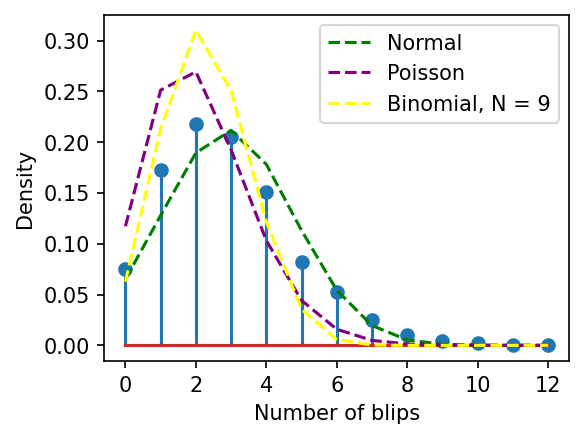

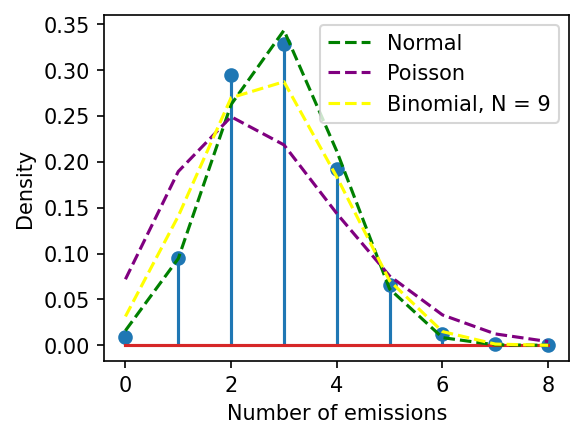

In [38]:
##More plots

plt.figure(figsize=(4, 3), dpi=150)
plt.stem(np.bincount(blips.astype('int'))/np.sum(np.bincount(blips.astype('int'))))
plt.plot(np.arange(blips.min(), blips.max() + 1),
         norm.pdf(np.arange(blips.min(), blips.max() + 1), loc_1, scale_1),
         label='Normal', color = 'g', linestyle = '--')
plt.plot(np.arange(0, np.bincount(blips.astype('int')).shape[0]),
         fishy(np.arange(blips.min(), blips.max() + 1),
         params1[0]), label='Poisson', color = 'purple', linestyle = '--')
plt.plot(np.arange(0, np.bincount(blips.astype('int')).shape[0]),
         twonom(np.arange(0, np.bincount(blips.astype('int')).shape[0]), *b_params1),
         label='Binomial, N = 9', color='yellow', linestyle='--')
plt.xlabel('Number of blips')
plt.ylabel('Density')
#plt.yscale('log')
#plt.axvline(x = np.mean(blips), linestyle = '--', color = 'k')
#plt.ylim(top=0.7)
""" plt.fill_betweenx(np.arange(0, 1, 0.1), np.mean(blips) - np.std(blips),
                  np.mean(blips) + np.std(blips), alpha = 0.3, color = 'orange', label = r'Error (1$\sigma$)') """
plt.legend()
plt.show()

plt.figure(figsize=(4, 3), dpi=150)
plt.stem(np.bincount(emissions.astype('int'))/np.sum(np.bincount(emissions.astype('int'))))
plt.plot(np.arange(emissions.min(), emissions.max() + 1),
         norm.pdf(np.arange(emissions.min(), emissions.max() + 1), loc_2, scale_2),
         label='Normal', color = 'g', linestyle = '--')
plt.plot(np.arange(emissions.min(), emissions.max() + 1),
         fishy(np.arange(emissions.min(), emissions.max() + 1),
         params2[0]), label='Poisson', color = 'purple', linestyle = '--')
plt.plot(np.arange(emissions.min(), emissions.max() + 1),
         twonom(np.arange(emissions.min(), emissions.max() + 1), *b_params2),
         label='Binomial, N = 9', color='yellow', linestyle='--')
plt.xlabel('Number of emissions')
plt.ylabel('Density')
#plt.yscale('log')
#plt.axvline(x = np.mean(emissions), linestyle = '--', color = 'k')
#plt.ylim(top=0.7)
""" plt.fill_betweenx(np.arange(0, 1, 0.1), np.mean(emissions) - np.std(emissions),
                  np.mean(emissions) + np.std(emissions), alpha = 0.3, color = 'orange', label = r'Error (1$\sigma$)') """
plt.legend()
plt.show()

In [39]:
print("Emissions, normal", np.std(np.bincount(emissions.astype('int'))/np.sum(np.bincount(emissions.astype('int'))) - norm.pdf(np.arange(emissions.min(), emissions.max() + 1), loc_2, scale_2)))
print("Emissions, poisson", np.std(np.bincount(emissions.astype('int'))/np.sum(np.bincount(emissions.astype('int'))) - fishy(np.arange(emissions.min(), emissions.max() + 1), params2[0])))

print("Blips, normal:", np.std(np.bincount(blips.astype('int'))/np.sum(np.bincount(blips.astype('int'))) - norm.pdf(np.arange(blips.min(), blips.max() + 1), loc_1, scale_1)))
print("Blips, fishy:", np.std(np.bincount(blips.astype('int'))/np.sum(np.bincount(blips.astype('int')))-fishy(np.arange(blips.min(), blips.max() + 1), params1[0])))

Emissions, normal 0.013669610716179666
Emissions, poisson 0.05788591117840287
Blips, normal: 0.018868668563604016
Blips, fishy: 0.03554617382314499


/Users/andreili/McGill_Physics/venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


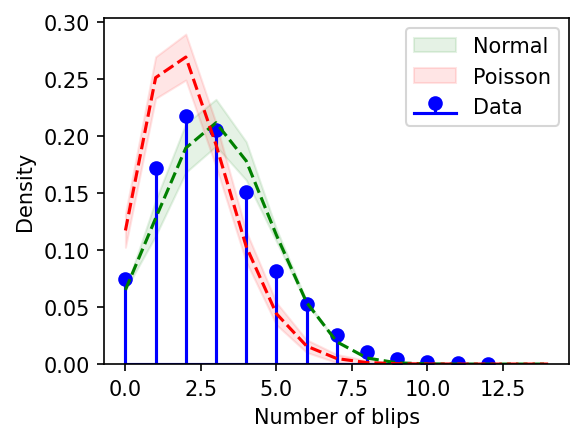

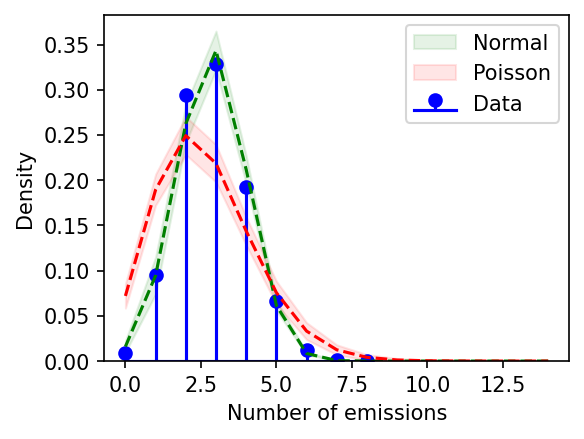

" sim_fish_blip_err = np.std(fish_blip_realizes, axis=0)\nsim_norm_blip_err = np.std(norm_blip_realizes, axis=0)\nsim_fish_emit_err = np.std(fish_emit_realizes, axis=0)\nsim_norm_emit_err = np.std(norm_emit_realizes, axis=0)\n\n\nplt.hist(sim_fish_blip_err, bins='auto', axis=)\nplt.hist(sim_norm_blip_err, bins='auto')\nplt.hist(sim_fish_emit_err, bins='auto')\nplt.hist(sim_norm_emit_err, bins='auto')\nplt.show() "

In [40]:
##Looking at errorbars from finite binning of data

counts = 100
b_events = blips.shape[0]
e_events = emissions.shape[0]

fish_blip_realizes = np.zeros(shape=(b_events, counts))
fish_emit_realizes = np.zeros(shape=(e_events, counts))
norm_blip_realizes = np.zeros(shape=(b_events, counts))
norm_emit_realizes = np.zeros(shape=(e_events, counts))

for m in range(counts):
    fish_blip_realizes[:, m] = poisson.rvs(params1[0], size=b_events)
    fish_emit_realizes[:, m] = poisson.rvs(params2[0], size=e_events)
    norm_blip_realizes[:, m] = st.truncnorm.rvs(-loc_1/scale_1, np.inf, loc=loc_1, size=b_events)
    norm_emit_realizes[:, m] = st.truncnorm.rvs(-loc_2/scale_2, np.inf, loc=loc_2, size=e_events)


fish_blip_bins = np.full((15, counts), np.nan)
fish_emit_bins = np.full((15, counts), np.nan)
norm_blip_bins = np.full((15, counts), np.nan)
norm_emit_bins = np.full((15, counts), np.nan)

for m in range(counts):
    
    arr = np.bincount(fish_blip_realizes.astype('int')[:, m])/np.sum(np.bincount(fish_blip_realizes.astype('int')[:, m]))
    fish_blip_bins[0:arr.shape[0], m] = arr

    arr = np.bincount(fish_emit_realizes.astype('int')[:, m])/np.sum(np.bincount(fish_emit_realizes.astype('int')[:, m]))
    fish_emit_bins[0:arr.shape[0], m] = arr

    arr = np.bincount(norm_blip_realizes.astype('int')[:, m])/np.sum(np.bincount(norm_blip_realizes.astype('int')[:, m]))
    norm_blip_bins[0:arr.shape[0], m] = arr

    arr = np.bincount(norm_emit_realizes.astype('int')[:, m])/np.sum(np.bincount(norm_emit_realizes.astype('int')[:, m]))
    norm_emit_bins[0:arr.shape[0], m] = arr



fish_blip_err = np.nanstd(fish_blip_bins, axis=1)
norm_blip_err = np.nanstd(norm_blip_bins, axis=1)
fish_emit_err = np.nanstd(fish_emit_bins, axis=1)
norm_emit_err = np.nanstd(norm_emit_bins, axis=1)

plt.figure(figsize=(4, 3), dpi=150)
plt.stem(np.bincount(blips.astype('int'))/np.sum(np.bincount(blips.astype('int'))), linefmt='b', markerfmt='b', basefmt='b', label='Data')
plt.fill_between(np.arange(0, 15, 1),
                 norm.pdf(np.arange(0, 15, 1), loc_1, scale_1) - 3*norm_blip_err,
                 norm.pdf(np.arange(0, 15, 1), loc_1, scale_1) + 3*norm_blip_err, alpha=0.1, color='g', label='Normal')
plt.fill_between(np.arange(0, 15, 1),
                 fishy(np.arange(0, 15, 1), params1[0]) - 3*fish_blip_err,
                 fishy(np.arange(0, 15, 1), params1[0]) + 3*fish_blip_err, alpha=0.1, color='r', label='Poisson')
plt.plot(np.arange(0, 15, 1), norm.pdf(np.arange(0, 15, 1), loc_1, scale_1), color='g', linestyle='--')
plt.plot(np.arange(0, 15, 1), fishy(np.arange(0, 15, 1), params1[0]), color='r', linestyle='--')
plt.ylim(0)
plt.xlabel('Number of blips')
plt.ylabel('Density')
plt.legend()
plt.show()

plt.figure(figsize=(4, 3), dpi=150)
plt.stem(np.bincount(emissions.astype('int'))/np.sum(np.bincount(emissions.astype('int'))), linefmt='b', markerfmt='b', basefmt='b', label='Data')
plt.plot(np.arange(0, 15, 1), norm.pdf(np.arange(0, 15, 1), loc_2, scale_2), color='g', linestyle='--')
plt.plot(np.arange(0, 15, 1), fishy(np.arange(0, 15, 1), params2[0]), color='r', linestyle='--')
plt.fill_between(np.arange(0, 15, 1),
                 norm.pdf(np.arange(0, 15, 1), loc_2, scale_2) - 3*norm_emit_err,
                 norm.pdf(np.arange(0, 15, 1), loc_2, scale_2) + 3*norm_emit_err, alpha=0.1, color='g', label='Normal')
plt.fill_between(np.arange(0, 15, 1),
                 fishy(np.arange(0, 15, 1), params2[0]) - 3*fish_emit_err,
                 fishy(np.arange(0, 15, 1), params2[0]) + 3*fish_emit_err, alpha=0.1, color='r', label='Poisson')
plt.ylim(0)
plt.xlabel('Number of emissions')
plt.ylabel('Density')
plt.legend()
plt.show()

""" sim_fish_blip_err = np.std(fish_blip_realizes, axis=0)
sim_norm_blip_err = np.std(norm_blip_realizes, axis=0)
sim_fish_emit_err = np.std(fish_emit_realizes, axis=0)
sim_norm_emit_err = np.std(norm_emit_realizes, axis=0)


plt.hist(sim_fish_blip_err, bins='auto', axis=)
plt.hist(sim_norm_blip_err, bins='auto')
plt.hist(sim_fish_emit_err, bins='auto')
plt.hist(sim_norm_emit_err, bins='auto')
plt.show() """


/var/folders/m_/qdkhzz6n1j3_fjt6_pj6ycv40000gn/T/ipykernel_23168/3347555223.py:4: RuntimeWarning: Mean of empty slice
  plt.plot(np.arange(0, fish_blip_err.shape[0]), fish_blip_err/np.nanmean(fish_blip_bins, axis=1), label='Poisson, blip')
/var/folders/m_/qdkhzz6n1j3_fjt6_pj6ycv40000gn/T/ipykernel_23168/3347555223.py:6: RuntimeWarning: Mean of empty slice
  plt.plot(np.arange(0, norm_blip_err.shape[0]), norm_blip_err/np.nanmean(norm_blip_bins, axis=1), label='Normal, blip')
/var/folders/m_/qdkhzz6n1j3_fjt6_pj6ycv40000gn/T/ipykernel_23168/3347555223.py:6: RuntimeWarning: invalid value encountered in divide
  plt.plot(np.arange(0, norm_blip_err.shape[0]), norm_blip_err/np.nanmean(norm_blip_bins, axis=1), label='Normal, blip')
/var/folders/m_/qdkhzz6n1j3_fjt6_pj6ycv40000gn/T/ipykernel_23168/3347555223.py:7: RuntimeWarning: Mean of empty slice
  plt.plot(np.arange(0, norm_emit_err.shape[0]), norm_emit_err/np.nanmean(norm_emit_bins, axis=1), label='Normal, emission')


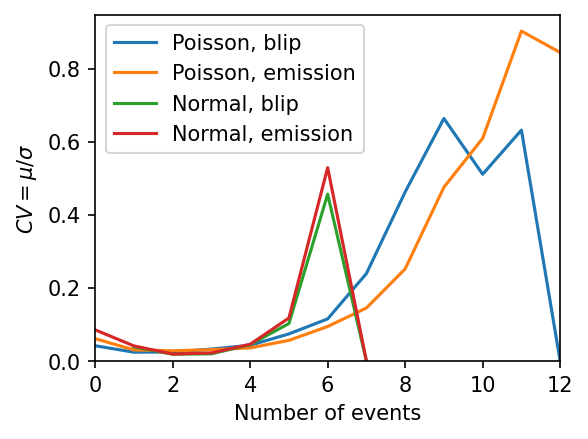

In [41]:
#Looking at error/mean

plt.figure(figsize=(4, 3), dpi=150)
plt.plot(np.arange(0, fish_blip_err.shape[0]), fish_blip_err/np.nanmean(fish_blip_bins, axis=1), label='Poisson, blip')
plt.plot(np.arange(0, fish_emit_err.shape[0]), fish_emit_err/np.nanmean(fish_emit_bins, axis=1), label='Poisson, emission')
plt.plot(np.arange(0, norm_blip_err.shape[0]), norm_blip_err/np.nanmean(norm_blip_bins, axis=1), label='Normal, blip')
plt.plot(np.arange(0, norm_emit_err.shape[0]), norm_emit_err/np.nanmean(norm_emit_bins, axis=1), label='Normal, emission')
plt.xlabel('Number of events')
plt.ylabel(r'$CV = \mu/\sigma$')
plt.legend()
plt.xlim(0, 12)
plt.ylim(0)
plt.show()

Number of blips: 6
Number of emissions: 2


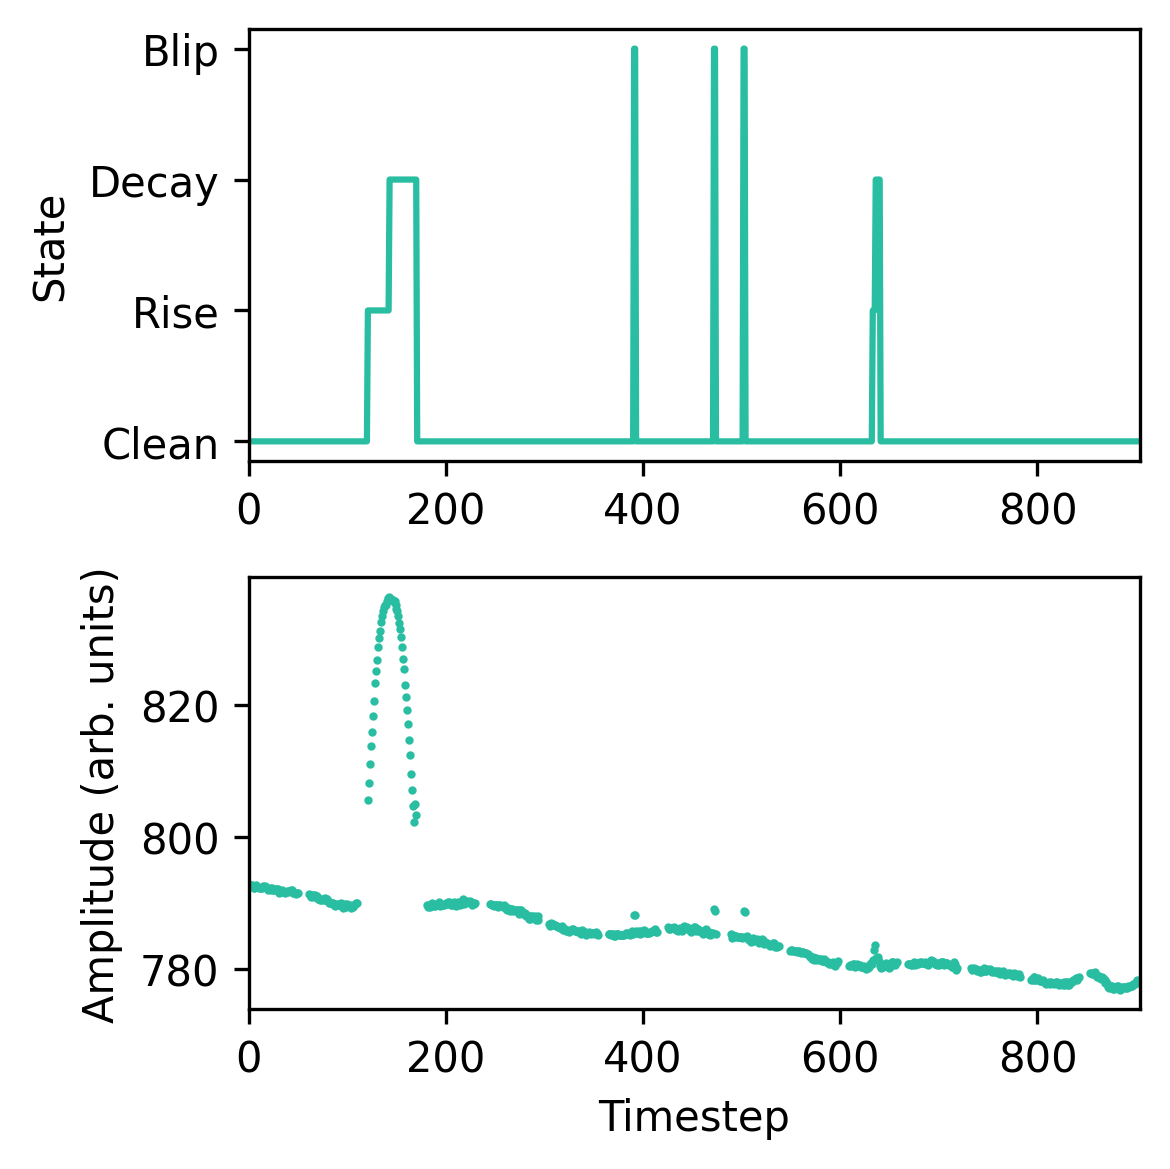

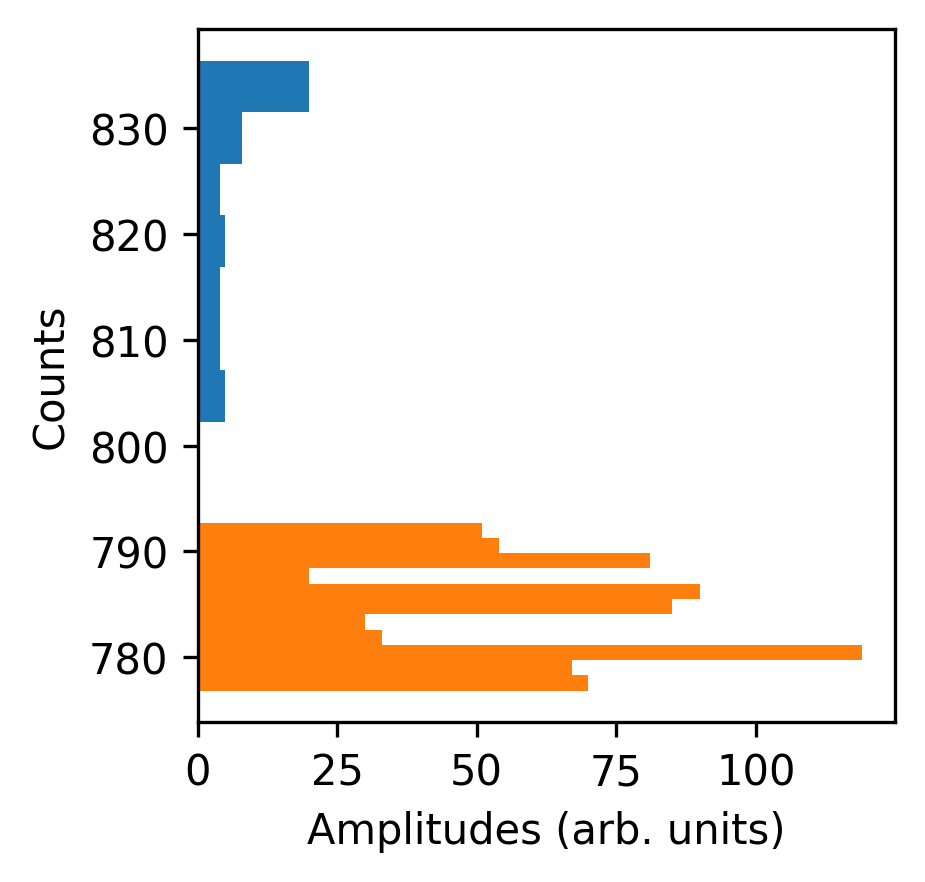

In [42]:
##Just some plotting code for different mixture model states

night = 109104
file = np.load(f"annotations/raw_data_{night}_p0.npy")
fig, ax = plt.subplots(figsize=(4, 4), nrows=2, dpi=300)
ax[0].plot(file, color='#29BDA2')
ax[0].set_yticks([1,2,3,4], ['Clean', 'Rise', 'Decay', 'Blip'])
print("Number of blips:", file[file==4].shape[0])
print("Number of emissions:", file[1:][(file[:-1] == 2) & (file[1:] == 3)].shape[0])
file2 = np.load(f"raw_data_p0/raw_data_{night}_p0.npy")
ax[1].scatter(np.arange(0, file2.shape[0])[file2 > 800], file2[file2 > 800], s=1, color="#29BDA2", alpha=1)
ax[1].scatter(np.arange(0, file2.shape[0])[file2 < 800], file2[file2 < 800], s=1, color='#29BDA2', alpha=1)
ax[1].set_xlabel("Timestep")
ax[1].set_ylabel("Amplitude (arb. units)")
ax[0].set_ylabel("State")
ax[0].set_xlim(0, file2.shape[0])
ax[1].set_xlim(0, file2.shape[0])
plt.tight_layout()
plt.show()

plt.figure(figsize=(3,3), dpi=300)
plt.hist(file2[file2 > 800], bins='auto', orientation='horizontal')
plt.hist(file2[file2 < 800], bins='auto', orientation='horizontal')
plt.ylabel("Counts")
plt.xlabel("Amplitudes (arb. units)")
plt.show()

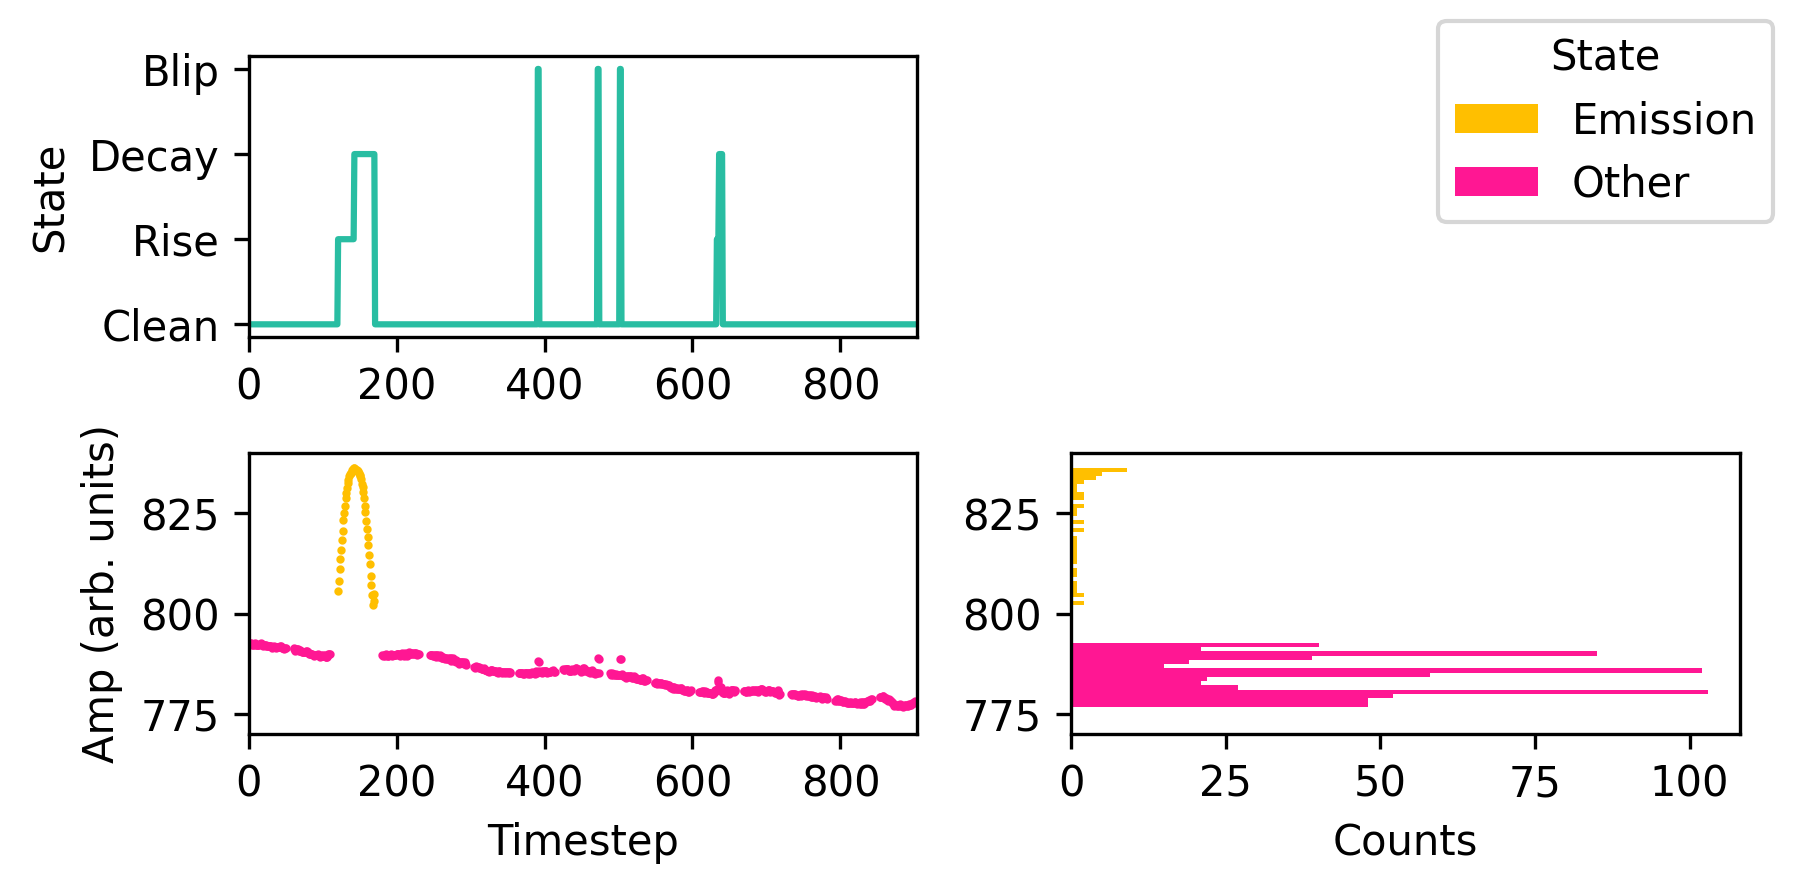

In [43]:
fig, axs = plt.subplots(2, 2, figsize=(6, 3), dpi=300)
# Delete the upper right subplot
fig.delaxes(axs[0, 1])

# Now use:
ax_left_top = axs[0, 0]
ax_left_bottom = axs[1, 0]
ax_right_bottom = axs[1, 1]


ax_left_top.plot(file, color='#29BDA2')
ax_left_top.set_yticks([1,2,3,4], ['Clean', 'Rise', 'Decay', 'Blip'])
ax_left_top.set_ylabel("State")
ax_left_top.set_xlim(0, file2.shape[0])

ax_left_bottom.plot([0, 1], [1, 0])
ax_left_bottom.scatter(np.arange(0, file2.shape[0])[file2 > 800], file2[file2 > 800], s=1, color="#FFBF00", alpha=1)
ax_left_bottom.scatter(np.arange(0, file2.shape[0])[file2 < 800], file2[file2 < 800], s=1, color="#FF1793", alpha=1)
ax_left_bottom.set_xlabel("Timestep")
ax_left_bottom.set_ylabel("Amp (arb. units)")
ax_left_bottom.set_xlim(0, file2.shape[0])
ax_left_bottom.set_ylim(770, 840)

ax_right_bottom.hist(file2[file2 > 800], bins=int((file2[file2 > 800].max()-file2[file2 > 800].min())), orientation='horizontal', color="#FFBF00", label='Emission')
ax_right_bottom.hist(file2[file2 < 800], bins=int((file2[file2 < 800].max()-file2[file2 < 800].min())), orientation='horizontal', color="#FF1793", label='Other')
ax_right_bottom.set_xlabel("Counts")
ax_right_bottom.set_ylim(770, 840)

fig.legend(title='State')

plt.tight_layout()
plt.show()

/var/folders/m_/qdkhzz6n1j3_fjt6_pj6ycv40000gn/T/ipykernel_23168/3216548447.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  fire[i] = st.gennorm.rvs(*fits[i, :], size=(1,))


(908, 1000)


' plt.figure(dpi=300, figsize=(5,3))\nplt.plot(background)\n#plt.xlim(scale-lims, 2*lims-scale)\nplt.xlabel("Time step")\nplt.ylabel("Amplitudes")\nplt.show()\nprint(background.shape) '

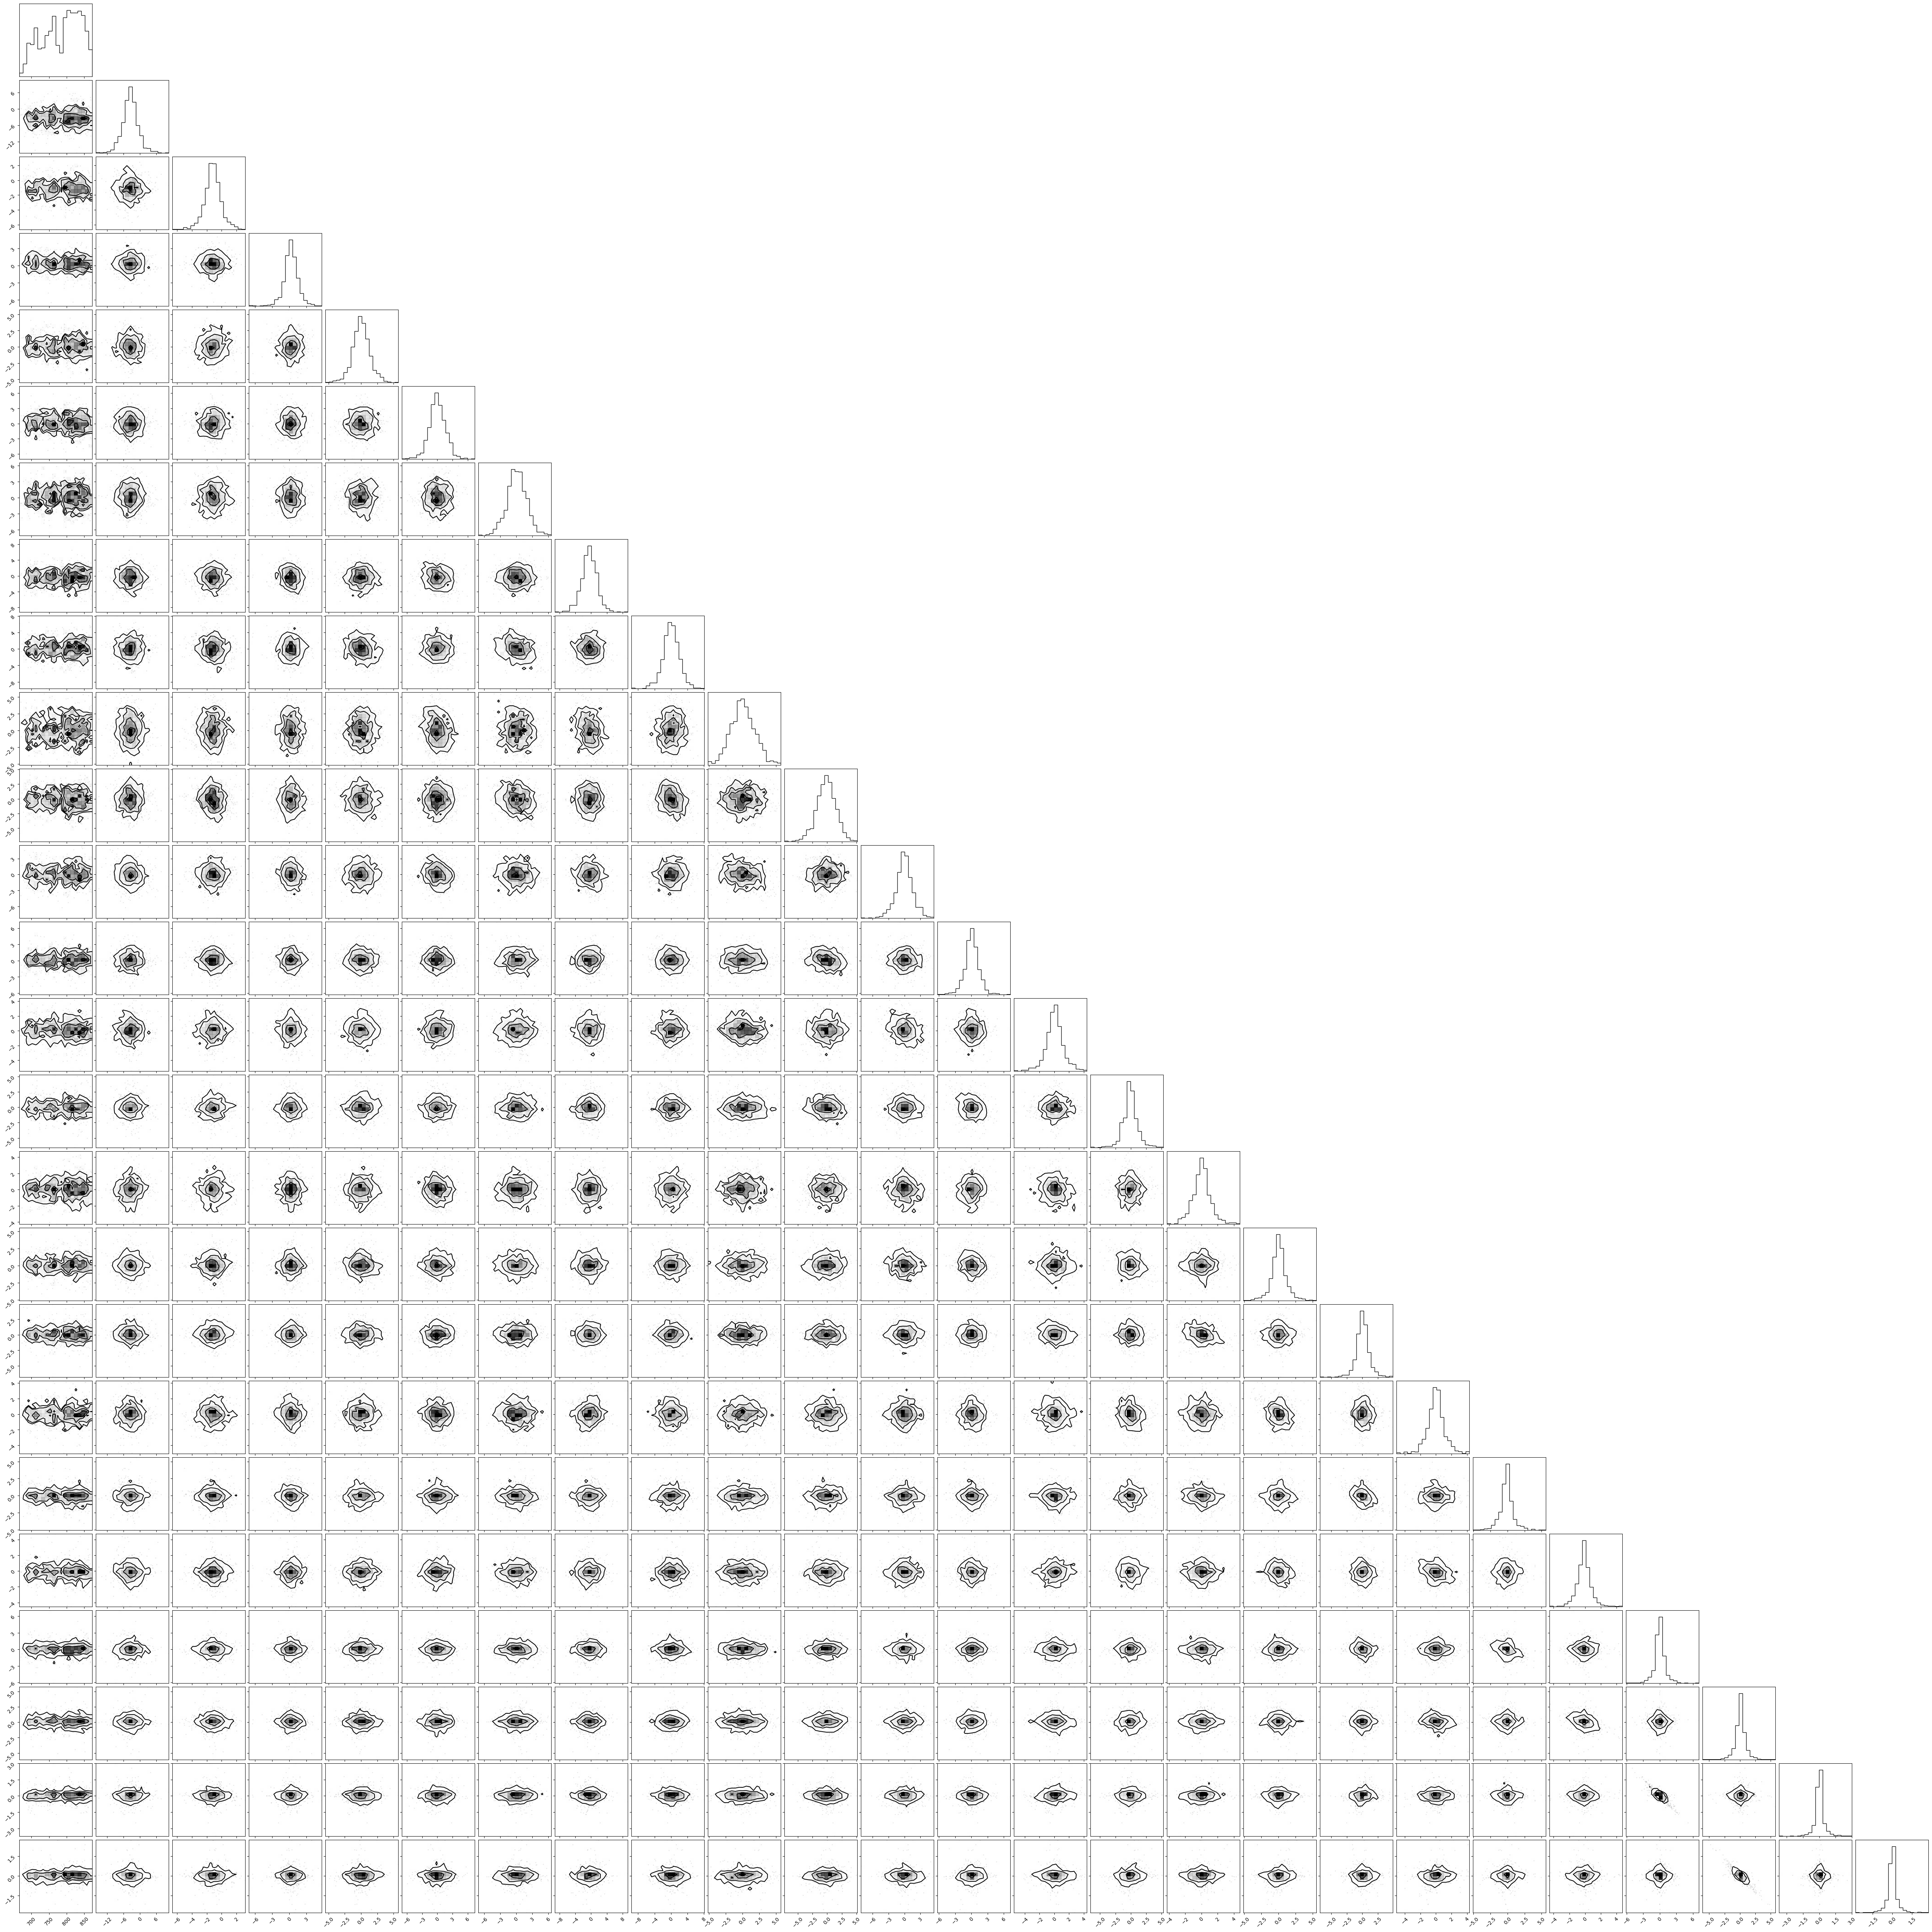

In [44]:
##Looking at how masks affect the coefficients -- generating coefficients, building fit, masking, then recalculating distribution

runs = 1000

background = np.empty(shape=(mask.shape[0], runs))
new_coeffs = np.empty(shape=(25, runs))

for k in range(runs):

    j = 0

    amps = slope[j] * (temps - T_0[j]) + y_int[j] + st.gennorm.rvs(beta[j], 0, alpha[j], size=(dots,))

    ##Generating smooth background

    #Summoning the L-coefficient parameters file
    fits = np.load('coeff_params_gnorm.npy')
    fire = np.empty_like(fits[:, 0])


    for i in range(fire.shape[0]):
        fire[i] = st.gennorm.rvs(*fits[i, :], size=(1,))
    fire = np.array(fire)

    rand_amp = np.random.choice(np.ndarray.flatten(amps))
    fire[0] = rand_amp
    temp_drawn = temps[amps == rand_amp]

    cut = 20

    mask = np.load('mask_example.npy').astype(bool)

    x = np.linspace(-1, 1, scale)
    X = legvander(x, fits.shape[0]-1)

    y = np.linspace(-1, 1, mask.shape[0])
    Y = legvander(y, fits.shape[0]-1)
    background[:, k] = (X @ fire)[cut:-cut]
    #plt.scatter(np.arange(0, mask.shape[0])[~mask], background[:, k][~mask], alpha=0.5, s=5, color='orange')
    new_coeffs[:, k] = np.linalg.solve((Y[~mask].T @ Y[~mask]), Y[~mask].T) @ background[:, k][~mask]
    #plt.plot(Y @ new_coeffs[:, k], color='blue')
    #print(X.shape)
    #print(Y.shape)

print(background.shape)

import corner
corner.corner(new_coeffs.T)

""" plt.figure(dpi=300, figsize=(5,3))
plt.plot(background)
#plt.xlim(scale-lims, 2*lims-scale)
plt.xlabel("Time step")
plt.ylabel("Amplitudes")
plt.show()
print(background.shape) """

(25, 1000)
(25, 3)


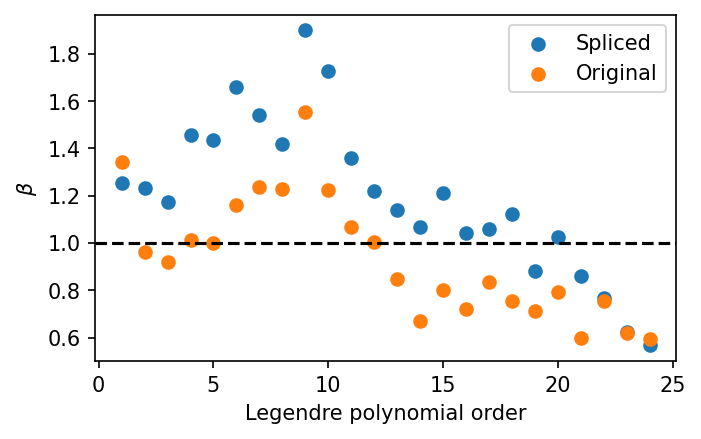

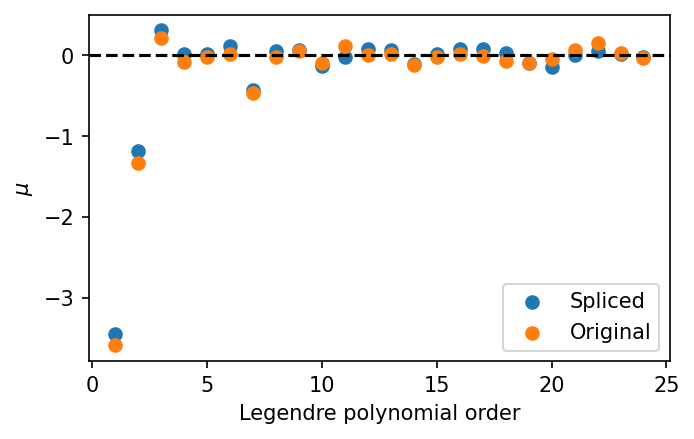

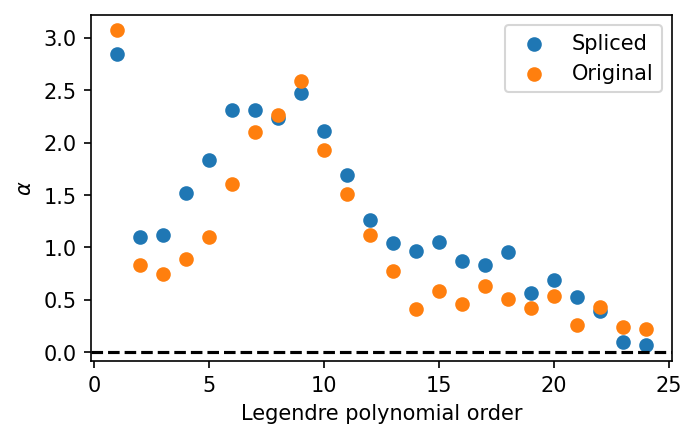

In [45]:
##Looking at hyperparameter distributions for coefficients

from scipy.stats import gennorm

params = gennorm.fit(new_coeffs[:, 0])
beta, loc, scale = params
coeff_params = np.array([beta, loc, scale])

print(new_coeffs.shape)

for i in range(1, new_coeffs.shape[0]):
    params = gennorm.fit(new_coeffs[i, :])
    beta, loc, scale = params
    coeff_params = np.vstack((coeff_params, np.array([beta, loc, scale])))

print(coeff_params.shape)

plt.figure(figsize=(5, 3), dpi=150)
plt.scatter(np.arange(1, 25), coeff_params[1:, 0], label="Spliced")
plt.scatter(np.arange(1, 25), fits[1:, 0], label="Original")
plt.xlabel("Legendre polynomial order")
plt.ylabel(r"$\beta$")
plt.legend()
plt.axhline(y=1, color='k', linestyle='--')
plt.show()

plt.figure(figsize=(5, 3), dpi=150)
plt.scatter(np.arange(1, 25), coeff_params[1:, 1], label="Spliced")
plt.scatter(np.arange(1, 25), fits[1:, 1], label='Original')
plt.xlabel("Legendre polynomial order")
plt.ylabel(r"$\mu$")
plt.legend()
plt.axhline(y=0, color='k', linestyle='--')
plt.show()

plt.figure(figsize=(5, 3), dpi=150)
plt.scatter(np.arange(1, 25), coeff_params[1:, 2], label='Spliced')
plt.scatter(np.arange(1, 25), fits[1:, 2], label='Original')
plt.xlabel("Legendre polynomial order")
plt.ylabel(r"$\alpha$")
plt.legend()
plt.axhline(y=0, color='k', linestyle='--')
plt.show()

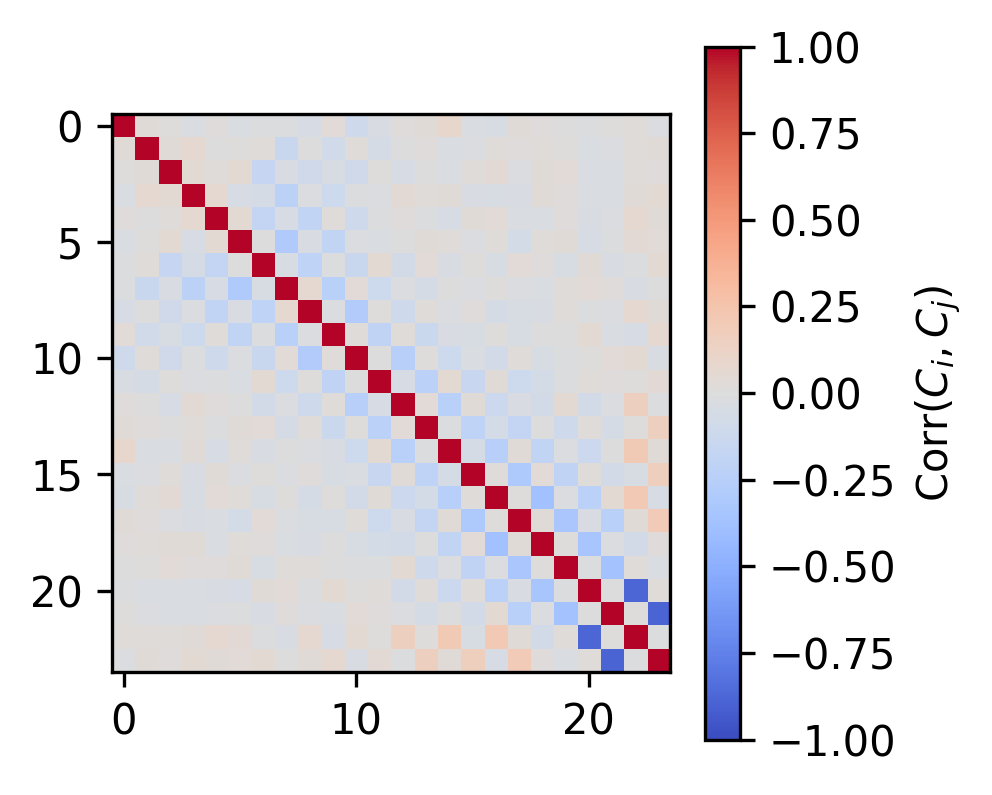

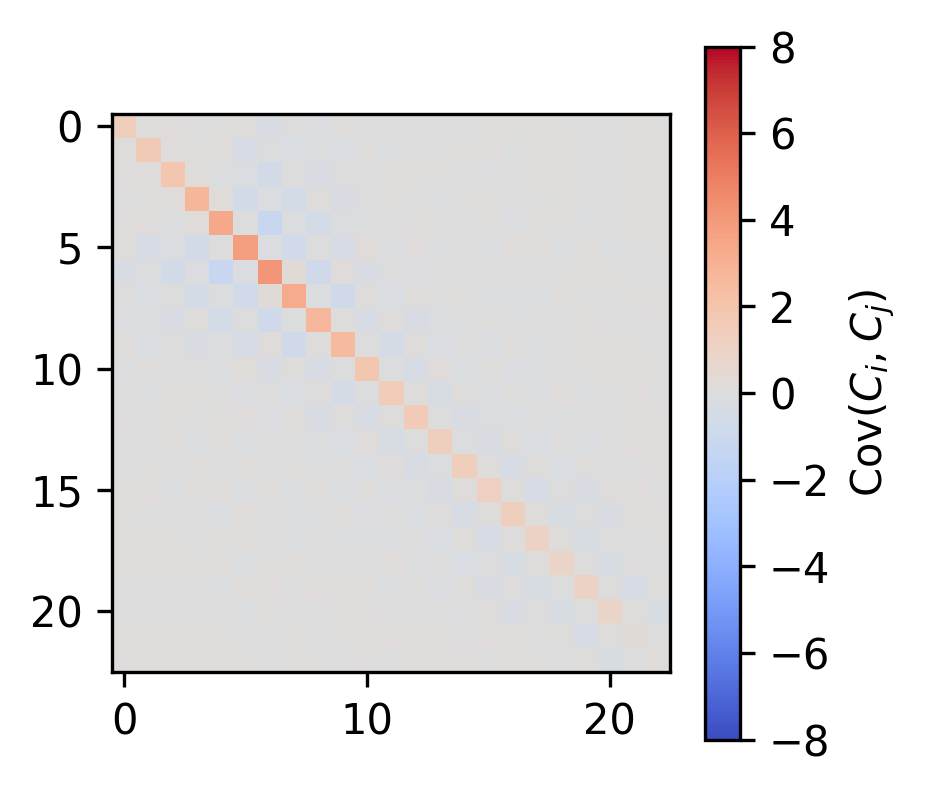

In [46]:
##Looking at the covariance/correlation matrix

corr_mat = np.corrcoef(new_coeffs[1:, :])
plt.figure(figsize=(3,3), dpi=300)
plt.imshow(corr_mat[:, :], cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label=r'$\text{Corr}(C_i, C_j)$')
plt.show()

cov_mat = np.cov(new_coeffs[1:, :])
plt.figure(figsize=(3,3), dpi=300)
plt.imshow(cov_mat[1:, 1:], cmap='coolwarm', vmax=8, vmin=-8)
plt.colorbar(label=r'$\text{Cov}(C_i, C_j)$')
plt.show()
